In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from  sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,roc_auc_score
from sklearn.metrics import accuracy_score,classification_report

import warnings
warnings.filterwarnings('ignore')


In [5]:
df=pd.read_csv("heart_failure_clinical_records_dataset.csv")
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


Q1. Data Overview
Load the dataset and show:
Number of rows & columns
Data types
Summary statistics (mean, median, min, max)
What does each feature represent in real world (short explanation)?

In [10]:
df.shape

(299, 13)

In [7]:
df.dtypes

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

In [8]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [31]:
df.median()

age                             60.0
anaemia                          0.0
creatinine_phosphokinase       250.0
diabetes                         0.0
ejection_fraction               38.0
high_blood_pressure              0.0
platelets                   262000.0
serum_creatinine                 1.1
serum_sodium                   137.0
sex                              1.0
smoking                          0.0
time                           115.0
DEATH_EVENT                      0.0
dtype: float64

Q2. Data Quality Check
Are there any missing values? If yes, decide how to handle them with justification.

In [15]:
print(df.isnull().sum())
df.duplicated().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


np.int64(0)

Q3. Distribution & Outliers
Plot histograms and box plots for these numeric features:
Age
Serum creatinine
Ejection fraction
For each, answer:
Are there outliers?
What does the distribution suggest about patient risk?

In [37]:
num_feature=['age','serum_creatinine','ejection_fraction']


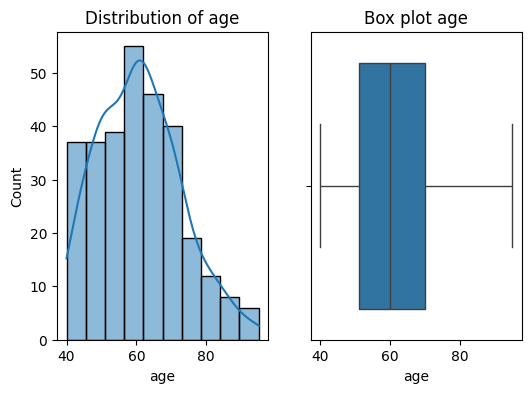

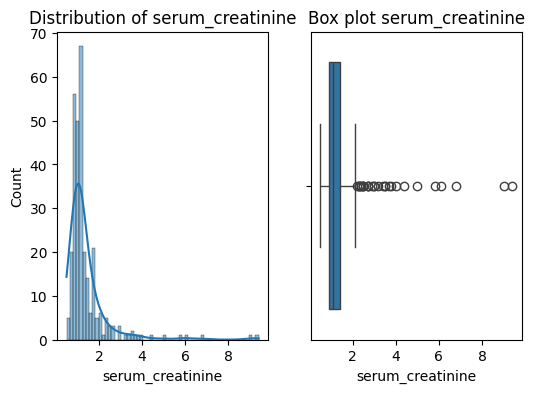

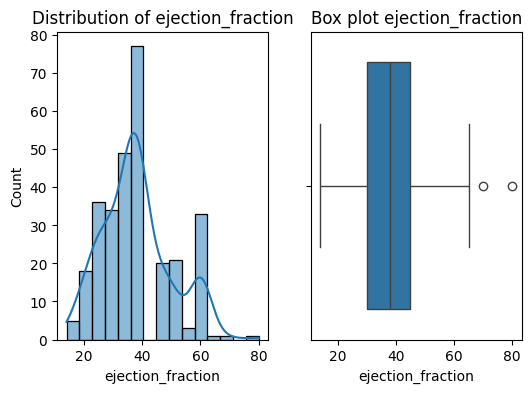

In [41]:
for col in num_feature:
    plt.figure(figsize=(6,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col],kde=True)
    plt.title(f"Distribution of {col}")
    

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Box plot {col}")
    plt.show()
   

Q4. Binary Relationships with Target
For each numerical feature below:
Plot it against DEATH_EVENT
Age
Ejection fraction
Serum sodium
Example output: “Patients older than ___ have higher death %.”

In [42]:
binary_rel=['age','serum_sodium','ejection_fraction']

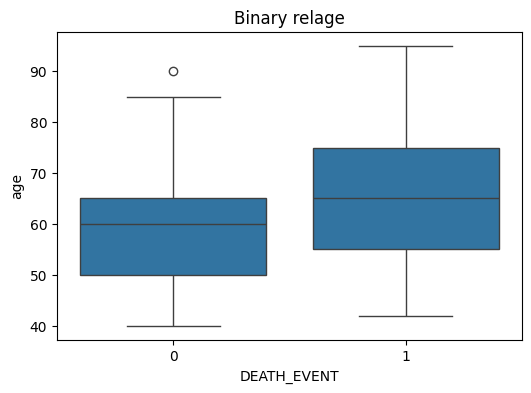

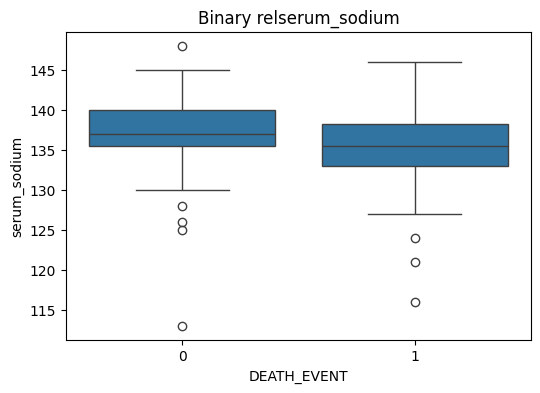

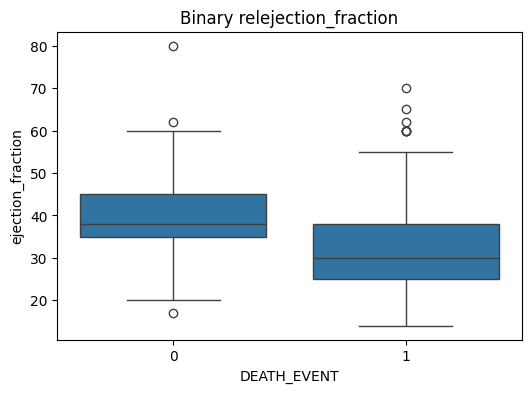

In [70]:
for col in binary_rel:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='DEATH_EVENT',y=col,data=df)
    plt.title(f"Binary rel{col}")
    plt.show()

Q5. Categorical Analysis
Convert sex, diabetes, smoking, high_blood_pressure, and anaemia to numeric if needed.
For each:
Create bar plots: Feature vs DEATH_EVENT
Give one real-world interpretation (not just count)

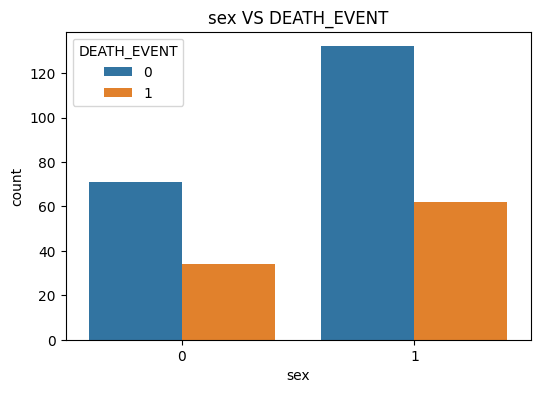

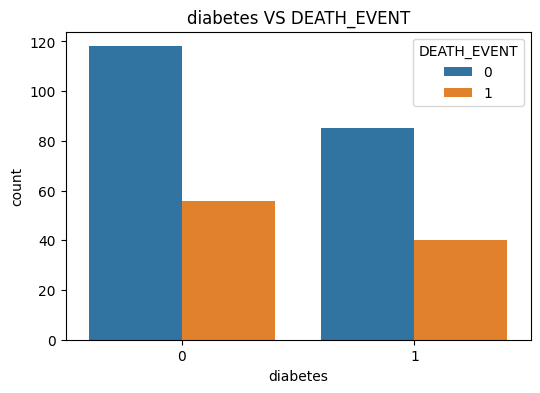

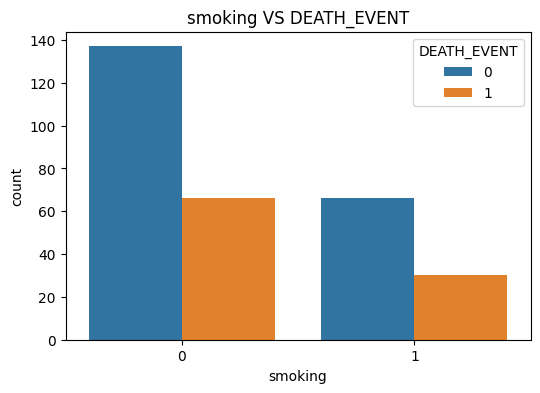

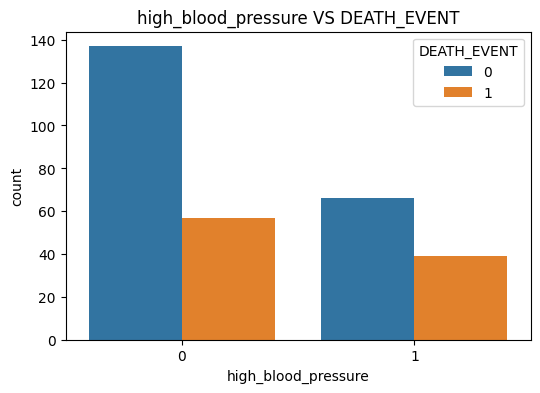

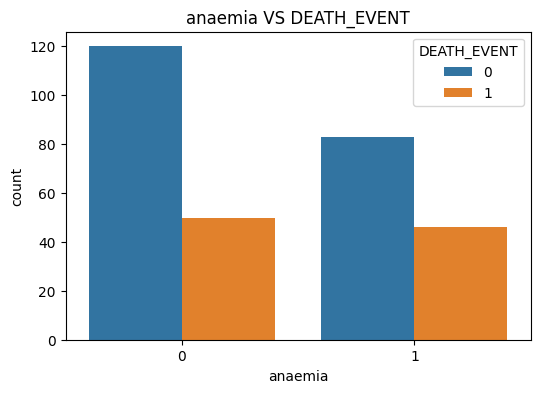

In [59]:
cat_freature=['sex','diabetes','smoking','high_blood_pressure','anaemia']
for col in cat_freature:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col,hue='DEATH_EVENT',data=df)
    plt.title(f"{col} VS DEATH_EVENT")
    plt.show()

Q6. Group Analysis
Create age groups (e.g., ≤50, 51–65, >65) and check survival rates per group.
Explain: Which age group seems most vulnerable and why medically might that be?

In [55]:
df['age_group']=pd.cut(
    df['age'],
    bins=[0,50,65,100],
    labels=['<=50','51-65','>65']
)

survival_rate=df.groupby('age_group')['DEATH_EVENT'].mean()
survival_rate

age_group
<=50     0.256757
51-65    0.257353
>65      0.471910
Name: DEATH_EVENT, dtype: float64

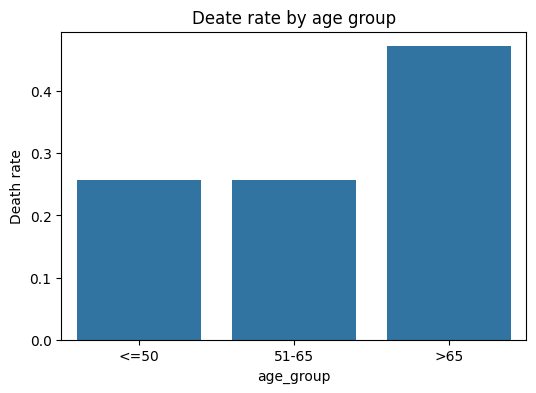

In [61]:
plt.figure(figsize=(6,4))
sns.barplot(x=survival_rate.index,y=survival_rate.values)
plt.title("Deate rate by age group")
plt.ylabel("Death rate")
plt.show()

Q7. Feature Correlation
Produce a heatmap of correlation among features and target.
Identify top 3 positively and negatively correlated features with DEATH_EVENT and interpret them.

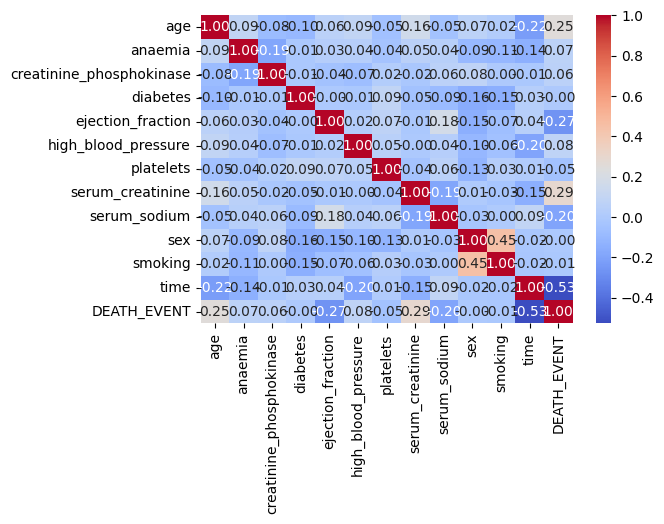

In [69]:
plt.figure(figsize=(6,4))
corr=df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f")
plt.show()